# Diffusion: from random motion to AI image generation

Many processes in nature involve random motion
 - Heat transport in solids
 - Virus particles spreading in air
 - Animals moving in ecosystems

Random motion looks unpredictable up close, but very predictable when you zoom out — and **AI image models learn how to reverse this randomness**.

We start by importing some standard Python libraries:

In [3]:
# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

## Part 1 — A single random particle

What are we modelling?
A particle that:

- starts at the origin,
- takes small random steps,
- has no memory.

This is called a **random walk**. We can code it up as follows:

In [4]:
# --- Simulation ---
def random_walk(n_steps=300, step_size=0.1, seed=0):
    rng = np.random.default_rng(seed)
    pos = np.zeros((n_steps + 1, 2))
    for t in range(n_steps):
        step = step_size * rng.standard_normal(2)
        # OTHER OPTIONS TO CHOOSE (UNCOMMENT)
        #step = step_size * rng.choice([-1, 1], size=2)
        #step = step_size * np.array([rng.standard_normal(), 0])
        pos[t + 1] = pos[t] + step
    return pos

And now run the simulation:

In [5]:
pos = random_walk(n_steps=50, step_size=0.2, seed=0)

It can be visualised interactively:

In [6]:
# --- Animation setup ---
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_aspect("equal")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_title("Random walk (diffusion)")

line, = ax.plot([], [], lw=2)
point, = ax.plot([], [], "ro")

def init():
    line.set_data([], [])
    point.set_data([], [])
    return line, point

def update(frame):
    line.set_data(pos[:frame, 0], pos[:frame, 1])
    point.set_data([pos[frame, 0]], [pos[frame, 1]])
    return line, point

anim = animation.FuncAnimation(
    fig,
    update,
    frames=len(pos),
    init_func=init,
    interval=50,
    blit=True
)

plt.close(fig)

# --- Display animation ---
HTML(anim.to_jshtml())

In [ ]:
# Backup if animation do not work
# anim.save("random_walk.gif", writer="pillow", fps=30)

# from IPython.display import Image
# Image(filename="random_walk.gif")


### Tasks:
- change value of `step_size` in `pos = random_walk(n_steps=50, step_size=0.2, seed=0)` above and rerun the code for interactive visualisation. What is different?
- try other random motions in the definition of `random_walk` (see commented out code)

## Part 2: many particles

What changes when we simulate many particles? Each particle is random — **but the cloud is not**.

We can simulate many random walks at the same time with the following code:

In [7]:
def many_particles(n_particles=500, n_steps=300, step_size=0.1, seed=0):
    rng = np.random.default_rng(seed)
    pos = np.zeros((n_steps + 1, n_particles, 2))

    for t in range(n_steps):
        steps = step_size * rng.standard_normal((n_particles, 2))
        pos[t + 1] = pos[t] + steps

    return pos

and now run the simulations with:

In [8]:
pos = many_particles(n_particles=500, n_steps=50, step_size=0.2, seed=0)

It can be visualised as follows:

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_aspect("equal")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_title("Many diffusing particles")

scat = ax.scatter([], [], s=5, alpha=0.5)

def init():
    scat.set_offsets(np.empty((0, 2)))
    return scat,

def update(frame):
    xy = pos[frame]
    scat.set_offsets(xy)
    return scat,

anim = animation.FuncAnimation(
    fig,
    update,
    frames=pos.shape[0],
    init_func=init,
    interval=50,
    blit=True
)

plt.close(fig)

HTML(anim.to_jshtml())

With many particles many properties can be predicted. For instance, as time $t$ grows, mathematical results establish that the average distance from the starting point should behave like $\sqrt{t}$. Lets verify this:

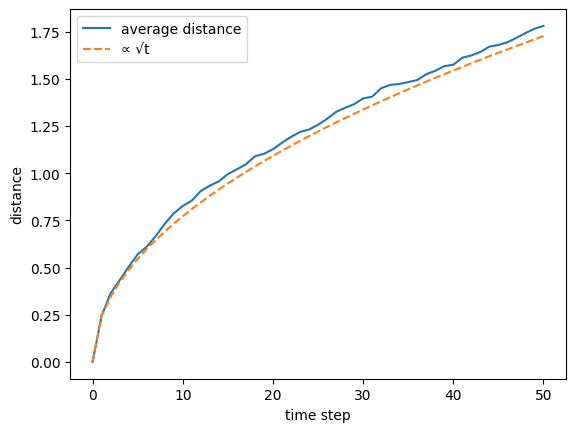

In [10]:
r = np.linalg.norm(pos, axis=2)
mean_r = r.mean(axis=1)

t = np.arange(len(mean_r))

plt.figure()
plt.plot(t, mean_r, label="average distance")
plt.plot(t, np.sqrt(t)*mean_r[1]/np.sqrt(1), "--", label="∝ √t")
plt.xlabel("time step")
plt.ylabel("distance")
plt.legend()
plt.show()

## Part 3 — From particles to pixels

- A pixel value is just a number.
- We can treat each pixel like a 1D particle.
- Adding noise to an image = many particles diffusing independently.

Let us first redo the above many participle simulation but in 1D:

In [10]:
def diffuse_1d(n_particles=10000, n_steps=200, step_size=0.1, seed=0):
    rng = np.random.default_rng(seed)
    x = np.zeros((n_steps + 1, n_particles))
    for t in range(n_steps):
        x[t+1] = x[t] + step_size * rng.standard_normal(n_particles)
    return x

In [11]:
x = diffuse_1d(n_particles=3000, n_steps=200, step_size=0.1, seed=0)

In [12]:
fig, ax = plt.subplots(figsize=(6, 3))

ax.set_xlim(-4, 4)
ax.set_ylim(-0.1, 0.1)
ax.set_yticks([])
ax.set_xlabel("position")
ax.set_title("1D diffusion (same random walk, but 1D)")

scat = ax.scatter([], [], s=5, alpha=0.5)

def init():
    scat.set_offsets(np.empty((0, 2)))
    return scat,

def update(frame):
    y = np.zeros_like(x[frame])  # all points on a line
    offsets = np.column_stack((x[frame], y))
    scat.set_offsets(offsets)
    return scat,

anim = animation.FuncAnimation(
    fig,
    update,
    frames=x.shape[0],
    init_func=init,
    interval=40,
    blit=True
)

plt.close(fig)
HTML(anim.to_jshtml())

This is visually less pleasing, but one key insight is to plot **histograms**, which answer the following question:

**“At this time step, where are most of the particles?”**

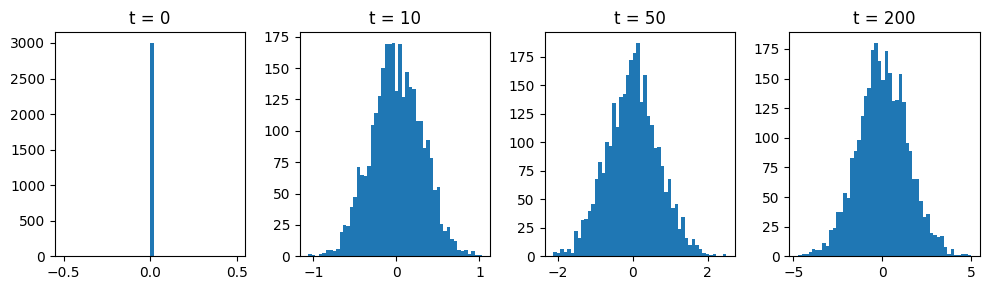

In [13]:
times = [0, 10, 50, 200]

plt.figure(figsize=(10,3))
for i, t in enumerate(times):
    plt.subplot(1, len(times), i+1)
    plt.hist(x[t], bins=50, density=False)
    plt.title(f"t = {t}")
plt.tight_layout()
plt.show()

Let us now load a grayscale example image from the leading open source machine learning library for image manipulation:

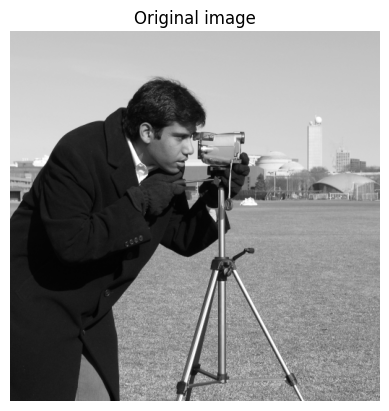

In [14]:
from skimage import data, img_as_float

img = img_as_float(data.camera())
plt.imshow(img, cmap="gray")
plt.title("Original image")
plt.axis("off")
plt.show()

We can diffuse the pixels:

In [15]:
def diffuse_image(image, sigma, seed=0):
    rng = np.random.default_rng(seed)
    return image + sigma * rng.standard_normal(image.shape)

and obtain noisy images:

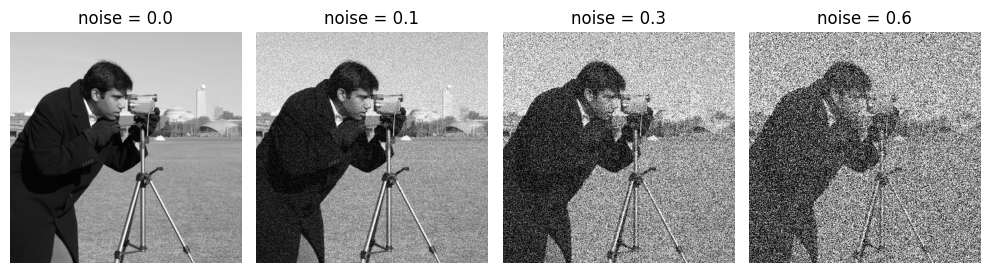

In [16]:
sigmas = [0.0, 0.1, 0.3, 0.6]

plt.figure(figsize=(10,3))
for i, s in enumerate(sigmas):
    noisy = diffuse_image(img, s)
    #noisy = np.clip(noisy, 0, 1)
    plt.subplot(1, len(sigmas), i+1)
    plt.imshow(np.clip(noisy, 0, 1), cmap="gray")
    plt.title(f"noise = {s}")
    plt.axis("off")
plt.tight_layout()
plt.show()

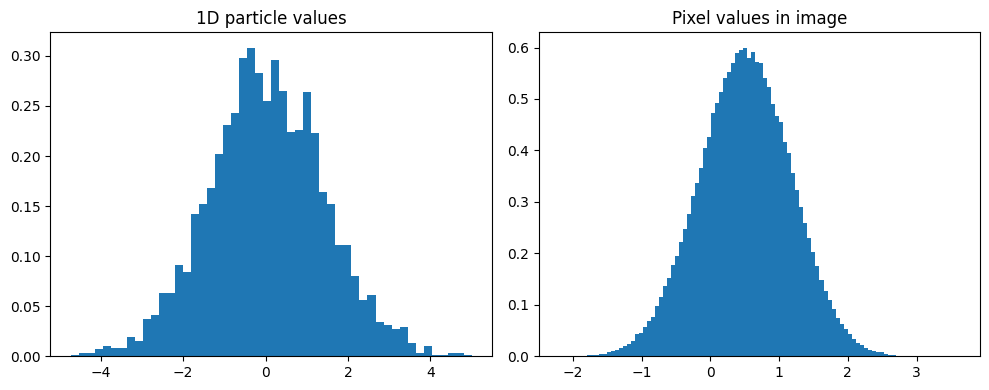

In [17]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(x[200], bins=50, density=True)
plt.title("1D particle values")

plt.subplot(1,2,2)
plt.hist(noisy.flatten(), bins=100, density=True)
plt.title("Pixel values in image")

plt.tight_layout()
plt.show()


## Part 4 - AI

[simple live demo of turning noise into an image goes here]